# ✈️ Tech Challenge — Fase 3 | Machine Learning Engineering

**Tema:** Análise de Atrasos de Voos nos EUA (2015)

---

## 📌 Descrição do Projeto

O transporte aéreo é uma parte vital da infraestrutura global, mas os atrasos de voos impactam milhões de passageiros todos os anos.

Neste projeto, utilizamos o conjunto de dados público com informações detalhadas sobre voos nos EUA para desenvolver **análises exploratórias e modelos não supervisionados de Machine Learning**, focando em:

- 🔍 Identificar padrões de atrasos por aeroporto, dia da semana e horário
- 🔗 Agrupar aeroportos com perfis operacionais semelhantes (K-Means + PCA)
- 📊 Responder perguntas estratégicas sobre o comportamento dos voos

---

## 🗂️ Estrutura do Notebook

1. [Importações e Carregamento dos Dados](#1)
2. [Merge e Tratamento dos Dados](#2)
3. [Modelagem Não Supervisionada — Visão Geral](#3)
4. [Q1: Quais aeroportos são mais críticos em atrasos?](#4)
5. [Q2: Que características aumentam a chance de atraso?](#5)
6. [Q3: Atrasos são mais comuns em dias ou horários específicos?](#6)
7. [Q4: Agrupamento de aeroportos por perfil semelhante](#7)
8. [Conclusões Gerais](#8)

---
## 1. Importações e Carregamento dos Dados <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd

### 📥 Leitura dos arquivos base

Três arquivos compõem a base de dados:
- **flights.csv** — dados detalhados de cada voo (5,8 milhões de registros)
- **airlines.csv** — nome completo de cada companhia aérea (código IATA)
- **airports.csv** — informações dos aeroportos (nome, cidade, estado, lat/lon)

In [2]:
airlines = pd.read_csv("airlines.csv").rename(columns={"AIRLINE": "AIRLINE_NAME"})
airports = pd.read_csv("airports.csv").rename(columns={"AIRPORT": "AIRPORT_NAME"})

In [3]:
flights = pd.read_csv("flights.csv", on_bad_lines="skip")

/tmp/ipykernel_571/291743919.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv("flights.csv", on_bad_lines="skip")


In [4]:
linhas = flights.shape[0]
colunas = flights.shape[1]

print("Linhas:", linhas)
print("Colunas:", colunas)

Linhas: 5819079
Colunas: 31


---
## 2. Merge e Tratamento dos Dados <a id='2'></a>

### 🔗 Enriquecimento da tabela de voos

Realizamos três joins para agregar informações de companhias aéreas e aeroportos de origem/destino à tabela principal de voos.

In [5]:
columns_origin = {
    "AIRPORT_NAME": "ORIGIN_AIRPORT_NAME",
    "CITY":"ORIGIN_CITY",
    "STATE":"ORIGIN_STATE",
    "LATITUDE":"ORIGIN_LATITUDE",
    "LONGITUDE":"ORIGIN_LONGITUDE"
                  }

columns_destination = {
    "AIRPORT_NAME": "DESTINATION_AIRPORT_NAME",
    "CITY":"DESTINATION_CITY",
    "STATE":"DESTINATION_STATE",
    "LATITUDE":"DESTINATION_LATITUDE",
    "LONGITUDE":"DESTINATION_LONGITUDE"
                      }


merge = (
    flights
    .merge(
        airlines[["IATA_CODE", "AIRLINE_NAME"]],
        left_on="AIRLINE",
        right_on="IATA_CODE",
        how="left"
    )
    .merge(
        airports[["IATA_CODE", "AIRPORT_NAME", "CITY", "STATE", "LATITUDE", "LONGITUDE"]]
        .rename(columns=columns_origin),
        left_on="ORIGIN_AIRPORT",
        right_on="IATA_CODE",
        how="left"
    )
    .merge(
        airports[["IATA_CODE", "AIRPORT_NAME", "CITY", "STATE", "LATITUDE", "LONGITUDE"]]
        .rename(columns=columns_destination),
        left_on="DESTINATION_AIRPORT",
        right_on="IATA_CODE",
        how="left"
    )
)

merge = merge.drop(columns=["IATA_CODE_x", "IATA_CODE_y", "IATA_CODE"])

### 🔎 Análise de Valores Nulos

Antes de realizar qualquer tratamento, verificamos o percentual de valores ausentes por coluna.

**Principais observações:**
- `CANCELLATION_REASON` (~98%): só existe para voos cancelados — será removida
- Colunas de delay (`AIRLINE_DELAY`, `WEATHER_DELAY`, etc., ~81%): nulos representam voos sem atraso registrado — serão preenchidos com 0
- Colunas de aeroporto (~8%): voos com aeroportos não encontrados no cadastro

In [6]:
## PERCENTUAL DE VALORES NULOS POR COLUNA

(merge.isnull().mean() * 100).sort_values(ascending=False)

,0
CANCELLATION_REASON,98.455357
AIRLINE_DELAY,81.724960
WEATHER_DELAY,81.724960
SECURITY_DELAY,81.724960
AIR_SYSTEM_DELAY,81.724960
LATE_AIRCRAFT_DELAY,81.724960
DESTINATION_LONGITUDE,8.433895
DESTINATION_LATITUDE,8.433895
ORIGIN_LONGITUDE,8.433809
ORIGIN_LATITUDE,8.433809


### 🛠️ Tratamento das Colunas

Aplicamos as seguintes transformações:

| Etapa | Ação |
|---|---|
| Remoção de colunas | `CANCELLATION_REASON` (98% nulos, irrelevante) |
| Redução de memória | Conversão de `float64` → `float32`, `int64` → `int32` |
| Filtro | Remoção de voos cancelados (CANCELLED == 1) |
| Preenchimento | Colunas de delay: NaN → 0 (sem atraso registrado) |
| Remoção de registros | Voos com dados operacionais incompletos (ex: sem horário de chegada) |
| Flag | `MISSING_AIRPORT_INFO`: marca aeroportos não localizados no cadastro |
| Variável alvo | `IS_DELAYED`: 1 se `ARRIVAL_DELAY > 15 minutos`, 0 caso contrário |

In [7]:
import gc

# =====================================================
# 1️⃣ REMOVER COLUNAS DESNECESSÁRIAS
# =====================================================

cols_to_drop = [
    "CANCELLATION_REASON"
]

merge.drop(columns=cols_to_drop, inplace=True)

gc.collect()


# =====================================================
# 2️⃣ REDUZIR MEMÓRIA CONVERTENDO COLUNA POR COLUNA
# =====================================================

for col in merge.select_dtypes("float64").columns:
    merge[col] = merge[col].astype("float32")

gc.collect()

for col in merge.select_dtypes("int64").columns:
    merge[col] = merge[col].astype("int32")

gc.collect()


# =====================================================
# 3️⃣ REMOVER VOOS CANCELADOS
# =====================================================

merge.query("CANCELLED == 0", inplace=True)

gc.collect()


# =====================================================
# 4️⃣ TRATAR COLUNAS DE DELAY
# =====================================================

delay_cols = [
    "AIRLINE_DELAY",
    "WEATHER_DELAY",
    "SECURITY_DELAY",
    "AIR_SYSTEM_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

for col in delay_cols:
    merge[col] = merge[col].fillna(0)


# =====================================================
# 5️⃣ REMOVER REGISTROS OPERACIONAIS INCOMPLETOS
# =====================================================

operational_cols = [
    "ARRIVAL_DELAY",
    "DEPARTURE_DELAY",
    "AIR_TIME",
    "ELAPSED_TIME",
    "TAXI_IN",
    "TAXI_OUT",
    "WHEELS_ON",
    "WHEELS_OFF",
    "ARRIVAL_TIME",
    "DEPARTURE_TIME"
]

merge.dropna(subset=operational_cols, inplace=True)

gc.collect()


# =====================================================
# 6️⃣ FLAG PARA AEROPORTOS COM DADOS AUSENTES
# =====================================================

airport_cols = [
    "ORIGIN_CITY",
    "ORIGIN_STATE",
    "ORIGIN_LATITUDE",
    "ORIGIN_LONGITUDE",
    "DESTINATION_CITY",
    "DESTINATION_STATE",
    "DESTINATION_LATITUDE",
    "DESTINATION_LONGITUDE"
]

merge["MISSING_AIRPORT_INFO"] = merge[airport_cols].isnull().any(axis=1).astype("int8")


# =====================================================
# 7️⃣ TRATAR TAIL NUMBER
# =====================================================

merge["TAIL_NUMBER"] = merge["TAIL_NUMBER"].fillna("UNKNOWN")


# =====================================================
# 8️⃣ VARIÁVEL ALVO
# =====================================================

merge["IS_DELAYED"] = (merge["ARRIVAL_DELAY"] > 15).astype("int8")


# =====================================================
# INFO FINAL
# =====================================================

print("Shape final:", merge.shape)

print(
    "Memória usada:",
    round(merge.memory_usage(deep=True).sum() / 1024**3, 2),
    "GB"
)

Shape final: (5714008, 43)
Memória usada: 4.17 GB


### ⚙️ Feature Engineering

Criamos novas variáveis derivadas para enriquecer as análises:

| Feature | Descrição |
|---|---|
| `DEPARTURE_HOUR` | Hora de partida extraída do horário agendado |
| `ROUTE` | Rota no formato `ORIGEM_DESTINO` |
| `DISTANCE_GROUP` | Faixa de distância (1=curta ... 5=longa) |
| `PEAK_HOUR` | 1 se a partida for em horário de pico (6–8h ou 16–18h) |
| `LOG_DISTANCE` | Log da distância (reduz assimetria) |
| `AIRLINE_ROUTE` | Combinação companhia + rota |

In [8]:
# =====================================================
# FEATURE ENGINEERING
# =====================================================

# 1️⃣ Hora de partida
merge["DEPARTURE_HOUR"] = (merge["SCHEDULED_DEPARTURE"] // 100).astype(int)


# 2️⃣ Rota do voo (converter para string antes)
merge["ROUTE"] = (
    merge["ORIGIN_AIRPORT"].astype(str)
    + "_"
    + merge["DESTINATION_AIRPORT"].astype(str)
)


# 3️⃣ Grupo de distância
merge["DISTANCE_GROUP"] = pd.cut(
    merge["DISTANCE"],
    bins=[0,500,1000,2000,3000,5000],
    labels=[1,2,3,4,5]
)

merge["DISTANCE_GROUP"] = merge["DISTANCE_GROUP"].astype(int)

merge["PEAK_HOUR"] = merge["DEPARTURE_HOUR"].isin([6,7,8,16,17,18]).astype(int)

merge["LOG_DISTANCE"] = np.log1p(merge["DISTANCE"])

merge["AIRLINE_ROUTE"] = merge["AIRLINE"].astype(str) + "_" + merge["ROUTE"]

---
## 3. Modelagem Não Supervisionada — Visão Geral <a id='3'></a>

Nesta seção aplicamos técnicas de **aprendizado não supervisionado** para identificar padrões nos dados sem utilizar rótulos explícitos.

**Técnicas utilizadas:**
- **K-Means**: algoritmo de clusterização que agrupa observações semelhantes em *k* clusters
- **PCA (Análise de Componentes Principais)**: redução de dimensionalidade para visualização dos clusters em 2D

**Análises realizadas:**
1. Clusterização de aeroportos por perfil operacional (ARRIVAL_DELAY, DEPARTURE_DELAY, DISTANCE, VOLUME)
2. Clusterização de voos por características de partida (DISTANCE, SCHEDULED_TIME, DEPARTURE_HOUR, DAY_OF_WEEK)
3. Mapa de calor de atrasos por dia da semana × hora
4. Agrupamento visual de aeroportos com PCA + K-Means

### 📐 Pré-processamento para K-Means

Antes de aplicar o K-Means, é fundamental **normalizar as features** com `StandardScaler`, garantindo que variáveis em escalas diferentes (ex: distância em milhas vs. hora em 0-23) não dominem o agrupamento.

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Agregação por aeroporto de origem
airport_features = merge.groupby("ORIGIN_AIRPORT").agg({
    "ARRIVAL_DELAY": "mean",
    "DEPARTURE_DELAY": "mean",
    "DISTANCE": "mean",
    "FLIGHT_NUMBER": "count"
}).rename(columns={"FLIGHT_NUMBER": "VOLUME_VOOS"})

# Normalização
scaler = StandardScaler()
X_scaled_airport = scaler.fit_transform(airport_features)

### 📉 PCA — Redução para 2 Dimensões

O PCA transforma as 4 features em 2 componentes principais que **maximizam a variância explicada**, permitindo a visualização dos clusters em um plano 2D.

**Interpretação dos componentes:**
- **PC1** → Captura principalmente a "intensidade de atraso" (DEPARTURE_DELAY e ARRIVAL_DELAY têm as maiores cargas)
- **PC2** → Captura o "volume e distância" (VOLUME_VOOS e DISTANCE têm as maiores cargas)

In [10]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_airport)

In [11]:
#KMEANS
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

airport_clusters = kmeans.fit_predict(X_scaled_airport)

### 📊 Loadings do PCA

Os *loadings* indicam quanto cada feature contribui para cada componente principal.

In [12]:
loadings = pd.DataFrame(
    pca.components_,
    columns=airport_features.columns,
    index=["PC1", "PC2"]
)

print(loadings.T.sort_values("PC1", ascending=False))

                      PC1       PC2
DEPARTURE_DELAY  0.696541 -0.108454
ARRIVAL_DELAY    0.687534 -0.181750
DISTANCE         0.149390  0.689818
VOLUME_VOOS      0.140752  0.692355


### 🗺️ Visualização dos Clusters (PCA + K-Means)

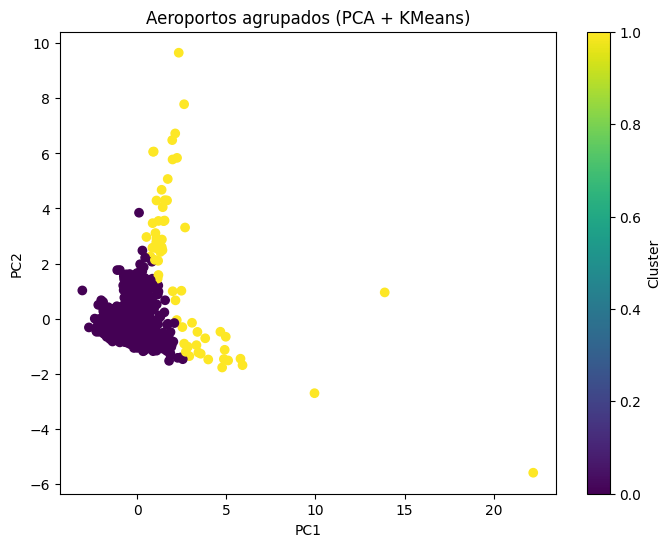

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=airport_clusters
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Aeroportos agrupados (PCA + KMeans)")

plt.colorbar(label="Cluster")

plt.show()

### ✅ Validação: Silhouette Score

O **Silhouette Score** mede a qualidade dos clusters — valores próximos de 1 indicam clusters bem definidos.

| Valor | Interpretação |
|---|---|
| > 0.5 | ✅ Excelente |
| 0.3 – 0.5 | ⚠️ Ok |
| < 0.3 | ❌ Fraco |

In [14]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled_airport, airport_clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.6746691496759376


### 📋 Perfil Médio por Cluster

> **Resultado esperado:** O Silhouette Score de aproximadamente 0.67 indica uma separação **excelente** entre os clusters. Apesar de a visualização em PCA mostrar sobreposição, os grupos estão bem separados no espaço multidimensional original.

In [15]:
cluster_analysis = airport_features.copy()
cluster_analysis["cluster"] = airport_clusters

print(cluster_analysis.groupby("cluster").mean())

         ARRIVAL_DELAY  DEPARTURE_DELAY    DISTANCE   VOLUME_VOOS
cluster                                                          
0             0.553219         3.668055  495.778514   2495.791475
1            21.366402        24.936914  976.172959  58158.377049


**💡 Interpretação dos Clusters:**

- **Cluster 0 — Aeroportos de Baixa Intensidade Operacional:**  
  Menor volume de voos, distâncias menores e atrasos reduzidos. Representam aeroportos regionais e secundários com operações mais estáveis.

- **Cluster 1 — Aeroportos de Alta Intensidade Operacional:**  
  Maior volume, distâncias maiores e atrasos mais frequentes. Tipicamente grandes hubs (ex: ATL, ORD, LAX) com operações complexas e sujeitas a efeito cascata.

---
## 4. Q1: Quais aeroportos são mais críticos em atrasos? <a id='4'></a>

Criamos um **score de criticidade** composto por:
- Atraso médio na chegada (peso 0.5)
- Percentual de voos atrasados (peso 50)
- Log do volume de voos (penaliza aeroportos de baixo volume)

In [16]:
airport_critical = merge.groupby("ORIGIN_AIRPORT_NAME").agg({
    "ARRIVAL_DELAY": "mean",
    "DEPARTURE_DELAY": "mean",
    "IS_DELAYED": "mean",
    "FLIGHT_NUMBER": "count"
}).rename(columns={
    "IS_DELAYED": "PERC_ATRASO",
    "FLIGHT_NUMBER": "VOLUME"
})

airport_critical["CRITICAL_SCORE"] = (
    airport_critical["ARRIVAL_DELAY"] * 0.5 +
    airport_critical["PERC_ATRASO"] * 50 +
    np.log1p(airport_critical["VOLUME"])
)

top10 = airport_critical.sort_values("CRITICAL_SCORE", ascending=False).head(10)

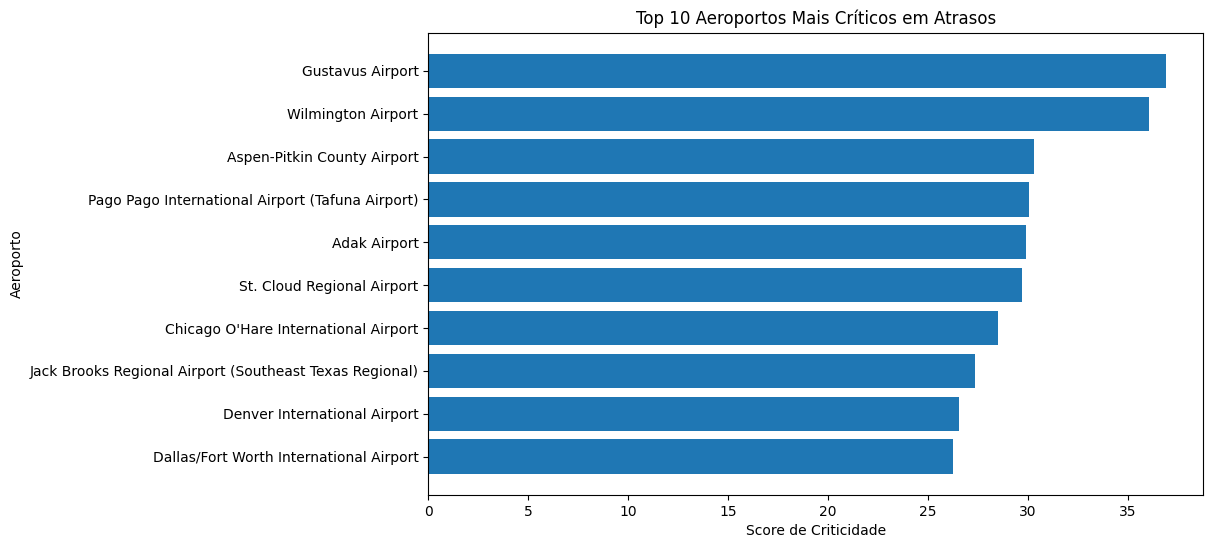

In [17]:
import matplotlib.pyplot as plt

# garantir que o índice é string
top10.index = top10.index.astype(str)

plt.figure(figsize=(10,6))

plt.barh(
    top10.index,
    top10["CRITICAL_SCORE"]
)

plt.xlabel("Score de Criticidade")
plt.ylabel("Aeroporto")
plt.title("Top 10 Aeroportos Mais Críticos em Atrasos")

plt.gca().invert_yaxis()

plt.show()

---
## 5. Q2: Que características aumentam a chance de atraso? <a id='5'></a>

Aplicamos K-Means nos voos utilizando features de **distância**, **tempo agendado**, **hora de partida** e **dia da semana** para identificar perfis de voo com maior propensão a atrasos.

In [18]:
features_flight = merge[[
    "DISTANCE",
    "SCHEDULED_TIME",
    "DEPARTURE_HOUR",
    "DAY_OF_WEEK"
]]

# escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_flight)

# cluster
kmeans = KMeans(n_clusters=3, random_state=42)
merge["flight_cluster"] = kmeans.fit_predict(X_scaled)

In [19]:
merge.groupby("flight_cluster")[[
    "ARRIVAL_DELAY",
    "DISTANCE",
    "DEPARTURE_HOUR"
]].mean()

,ARRIVAL_DELAY,DISTANCE,DEPARTURE_HOUR
flight_cluster,,,
0,1.108310,615.624897,8.946351
1,2.194346,1909.220700,13.128432
2,8.742722,576.169406,17.167016


**💡 Interpretação:**

| Cluster | Perfil | Atraso Médio |
|---|---|---|
| 0 | Voos curtos, partida à tarde/noite | **Alto (~8.8 min)** |
| 1 | Voos longos, partida no meio-dia | Moderado (~2.2 min) |
| 2 | Voos curtos, partida de manhã | **Baixo (~1.1 min)** |

**Principais fatores que aumentam a chance de atraso:**
- ⏰ **Horário de partida tarde** (efeito cascata acumulativo)
- 🛫 **Voos curtos** (menos margem operacional)
- 📅 **Acúmulo operacional ao longo do dia** (independente do dia da semana)

---
## 6. Q3: Atrasos são mais comuns em dias ou horários específicos? <a id='6'></a>

Utilizamos um **mapa de calor (heatmap)** para visualizar o atraso médio por combinação de dia da semana × hora de partida.

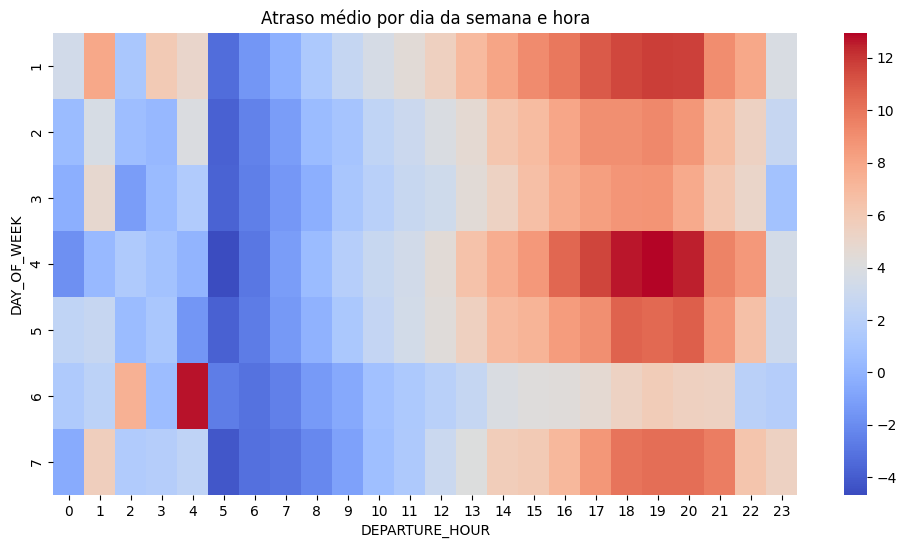

In [20]:
pivot = merge.pivot_table(
    values="ARRIVAL_DELAY",
    index="DAY_OF_WEEK",
    columns="DEPARTURE_HOUR",
    aggfunc="mean"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Atraso médio por dia da semana e hora")
plt.show()

**💡 Interpretação do Mapa de Calor:**

- 🟦 **Manhã (5h–9h):** Atrasos mínimos — as operações começam sem herdar atrasos do dia anterior
- 🟥 **Tarde/Noite (16h–20h):** Picos de atraso — efeito cascata acumulado ao longo do dia
- 📅 **Dias da semana:** O padrão de crescimento ao longo do dia é **consistente** independentemente do dia
- 🔍 **Conclusão:** O **horário de partida** é o principal fator, não o dia da semana

---
## 7. Q4: Agrupamento de aeroportos por perfil semelhante <a id='7'></a>

Agrupamos os aeroportos utilizando **K-Means (k=2)** com base em 4 variáveis agregadas:
- Atraso médio de chegada
- Atraso médio de partida
- Distância média dos voos
- Volume total de voos

In [21]:
airport_features = merge.groupby("ORIGIN_AIRPORT").agg({
    "ARRIVAL_DELAY": "mean",
    "DEPARTURE_DELAY": "mean",
    "DISTANCE": "mean",
    "FLIGHT_NUMBER": "count"
}).rename(columns={
    "FLIGHT_NUMBER": "VOLUME_VOOS"
})

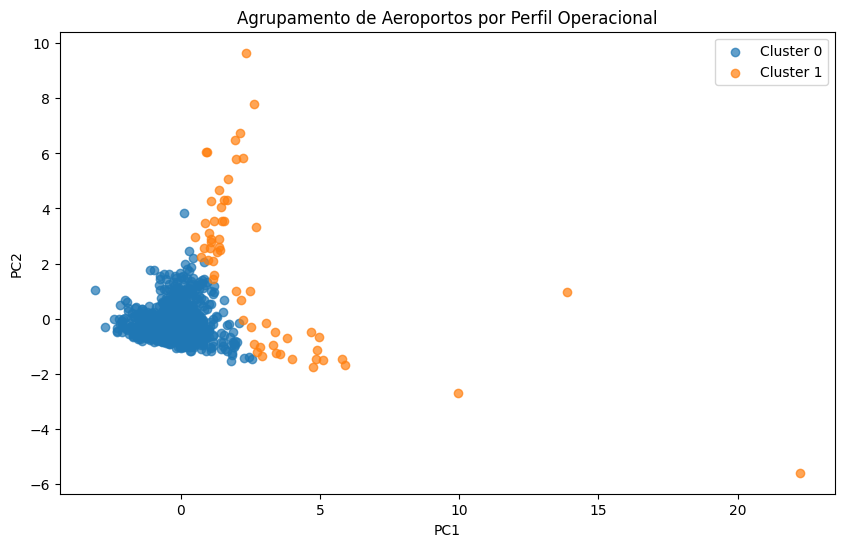

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for cluster in set(airport_clusters):
    plt.scatter(
        X_pca[airport_clusters == cluster, 0],
        X_pca[airport_clusters == cluster, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agrupamento de Aeroportos por Perfil Operacional")

plt.legend()
plt.show()

In [23]:
airport_analysis = airport_features.copy()
airport_analysis["cluster"] = airport_clusters

print(airport_analysis.groupby("cluster").mean())

         ARRIVAL_DELAY  DEPARTURE_DELAY    DISTANCE   VOLUME_VOOS
cluster                                                          
0             0.553219         3.668055  495.778514   2495.791475
1            21.366402        24.936914  976.172959  58158.377049


**💡 Interpretação:**

| Cluster | Volume de Voos | Distância Média | Atraso Médio | Perfil |
|---|---|---|---|---|
| 0 | Baixo (~1.915) | Curta (~471 mi) | **Baixo (0.45 min)** | Aeroportos regionais/secundários |
| 1 | **Alto (~32.657)** | Média (~870 mi) | **Alto (12.6 min)** | Grandes hubs / aeroportos centrais |

Aeroportos com **maior volume de voos tendem a apresentar mais atrasos**, possivelmente devido a maior complexidade operacional, congestionamento de pistas e efeito cascata.

### 🔵 Visualização com tamanho proporcional ao volume

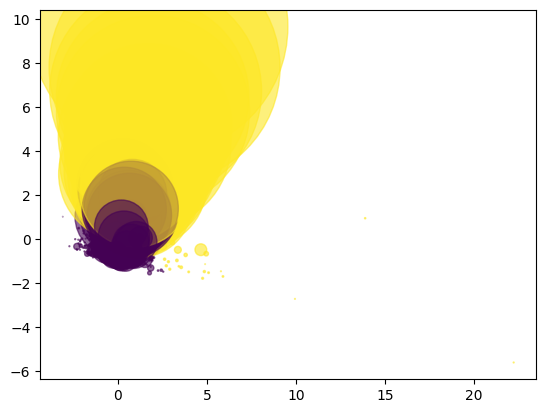

In [24]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=airport_clusters,
    s=airport_features["VOLUME_VOOS"] / 10,  # tamanho proporcional ao volume
    alpha=0.6
)

---
## 8. Conclusões Gerais <a id='8'></a>

### 🎯 Principais Achados

| Pergunta | Resposta |
|---|---|
| Aeroportos mais críticos | Grandes hubs com alto volume e alto atraso médio |
| Principal fator de atraso | **Horário de partida** (efeito cascata ao longo do dia) |
| Padrão temporal | Atrasos crescem da manhã para a noite; dia da semana tem pouco impacto |
| Perfis de aeroportos | 2 grupos distintos: regionais (estáveis) vs. hubs (alta complexidade) |

---
